<a href="https://colab.research.google.com/github/mondr653-ux/Final-Project-/blob/main/Portable_info_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated 2 QR codes.

QR Code for: DAL-001


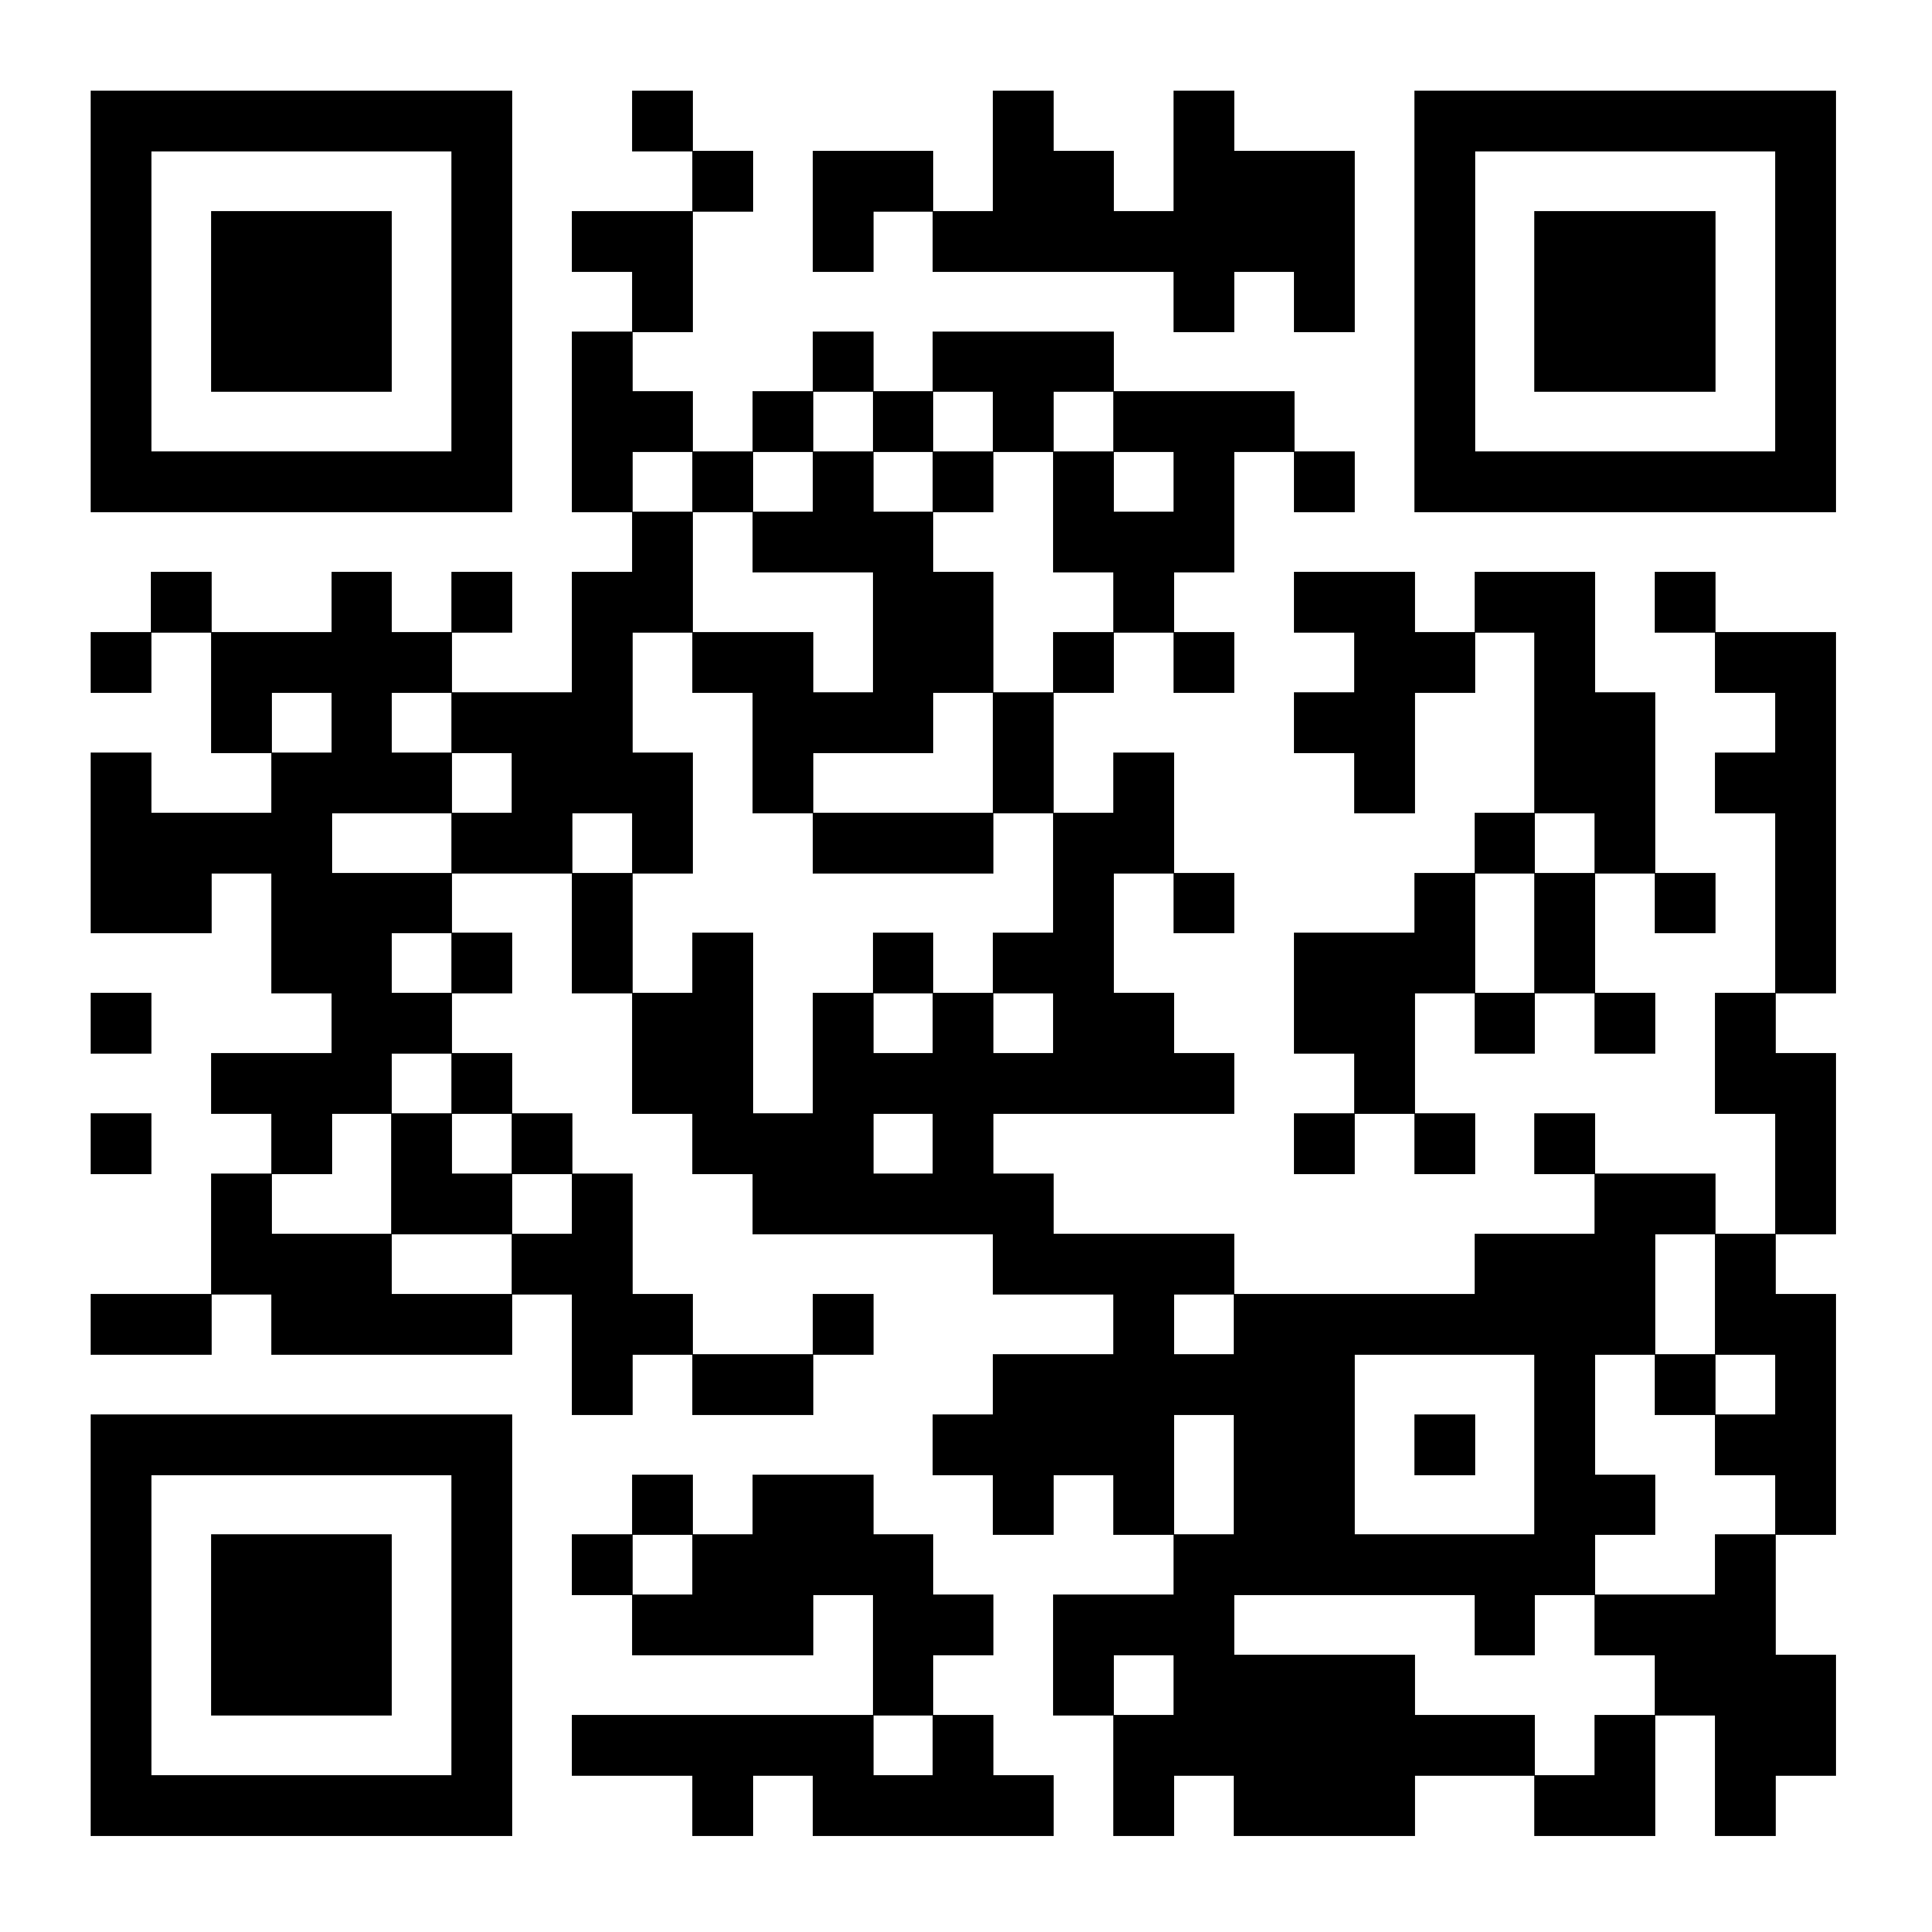

--- Product Safety Information: DAL-001 ---


,0
product_id,DAL-001
name,Organic Tomato Sauce
origin,"Parma, Italy"
safety_status,Certified Organic
allergens,None
expiry,2025-12-01
traceability_url,https://dalgiardino.com/mobile_demo/app4/app4_...



QR Code for: DAL-002


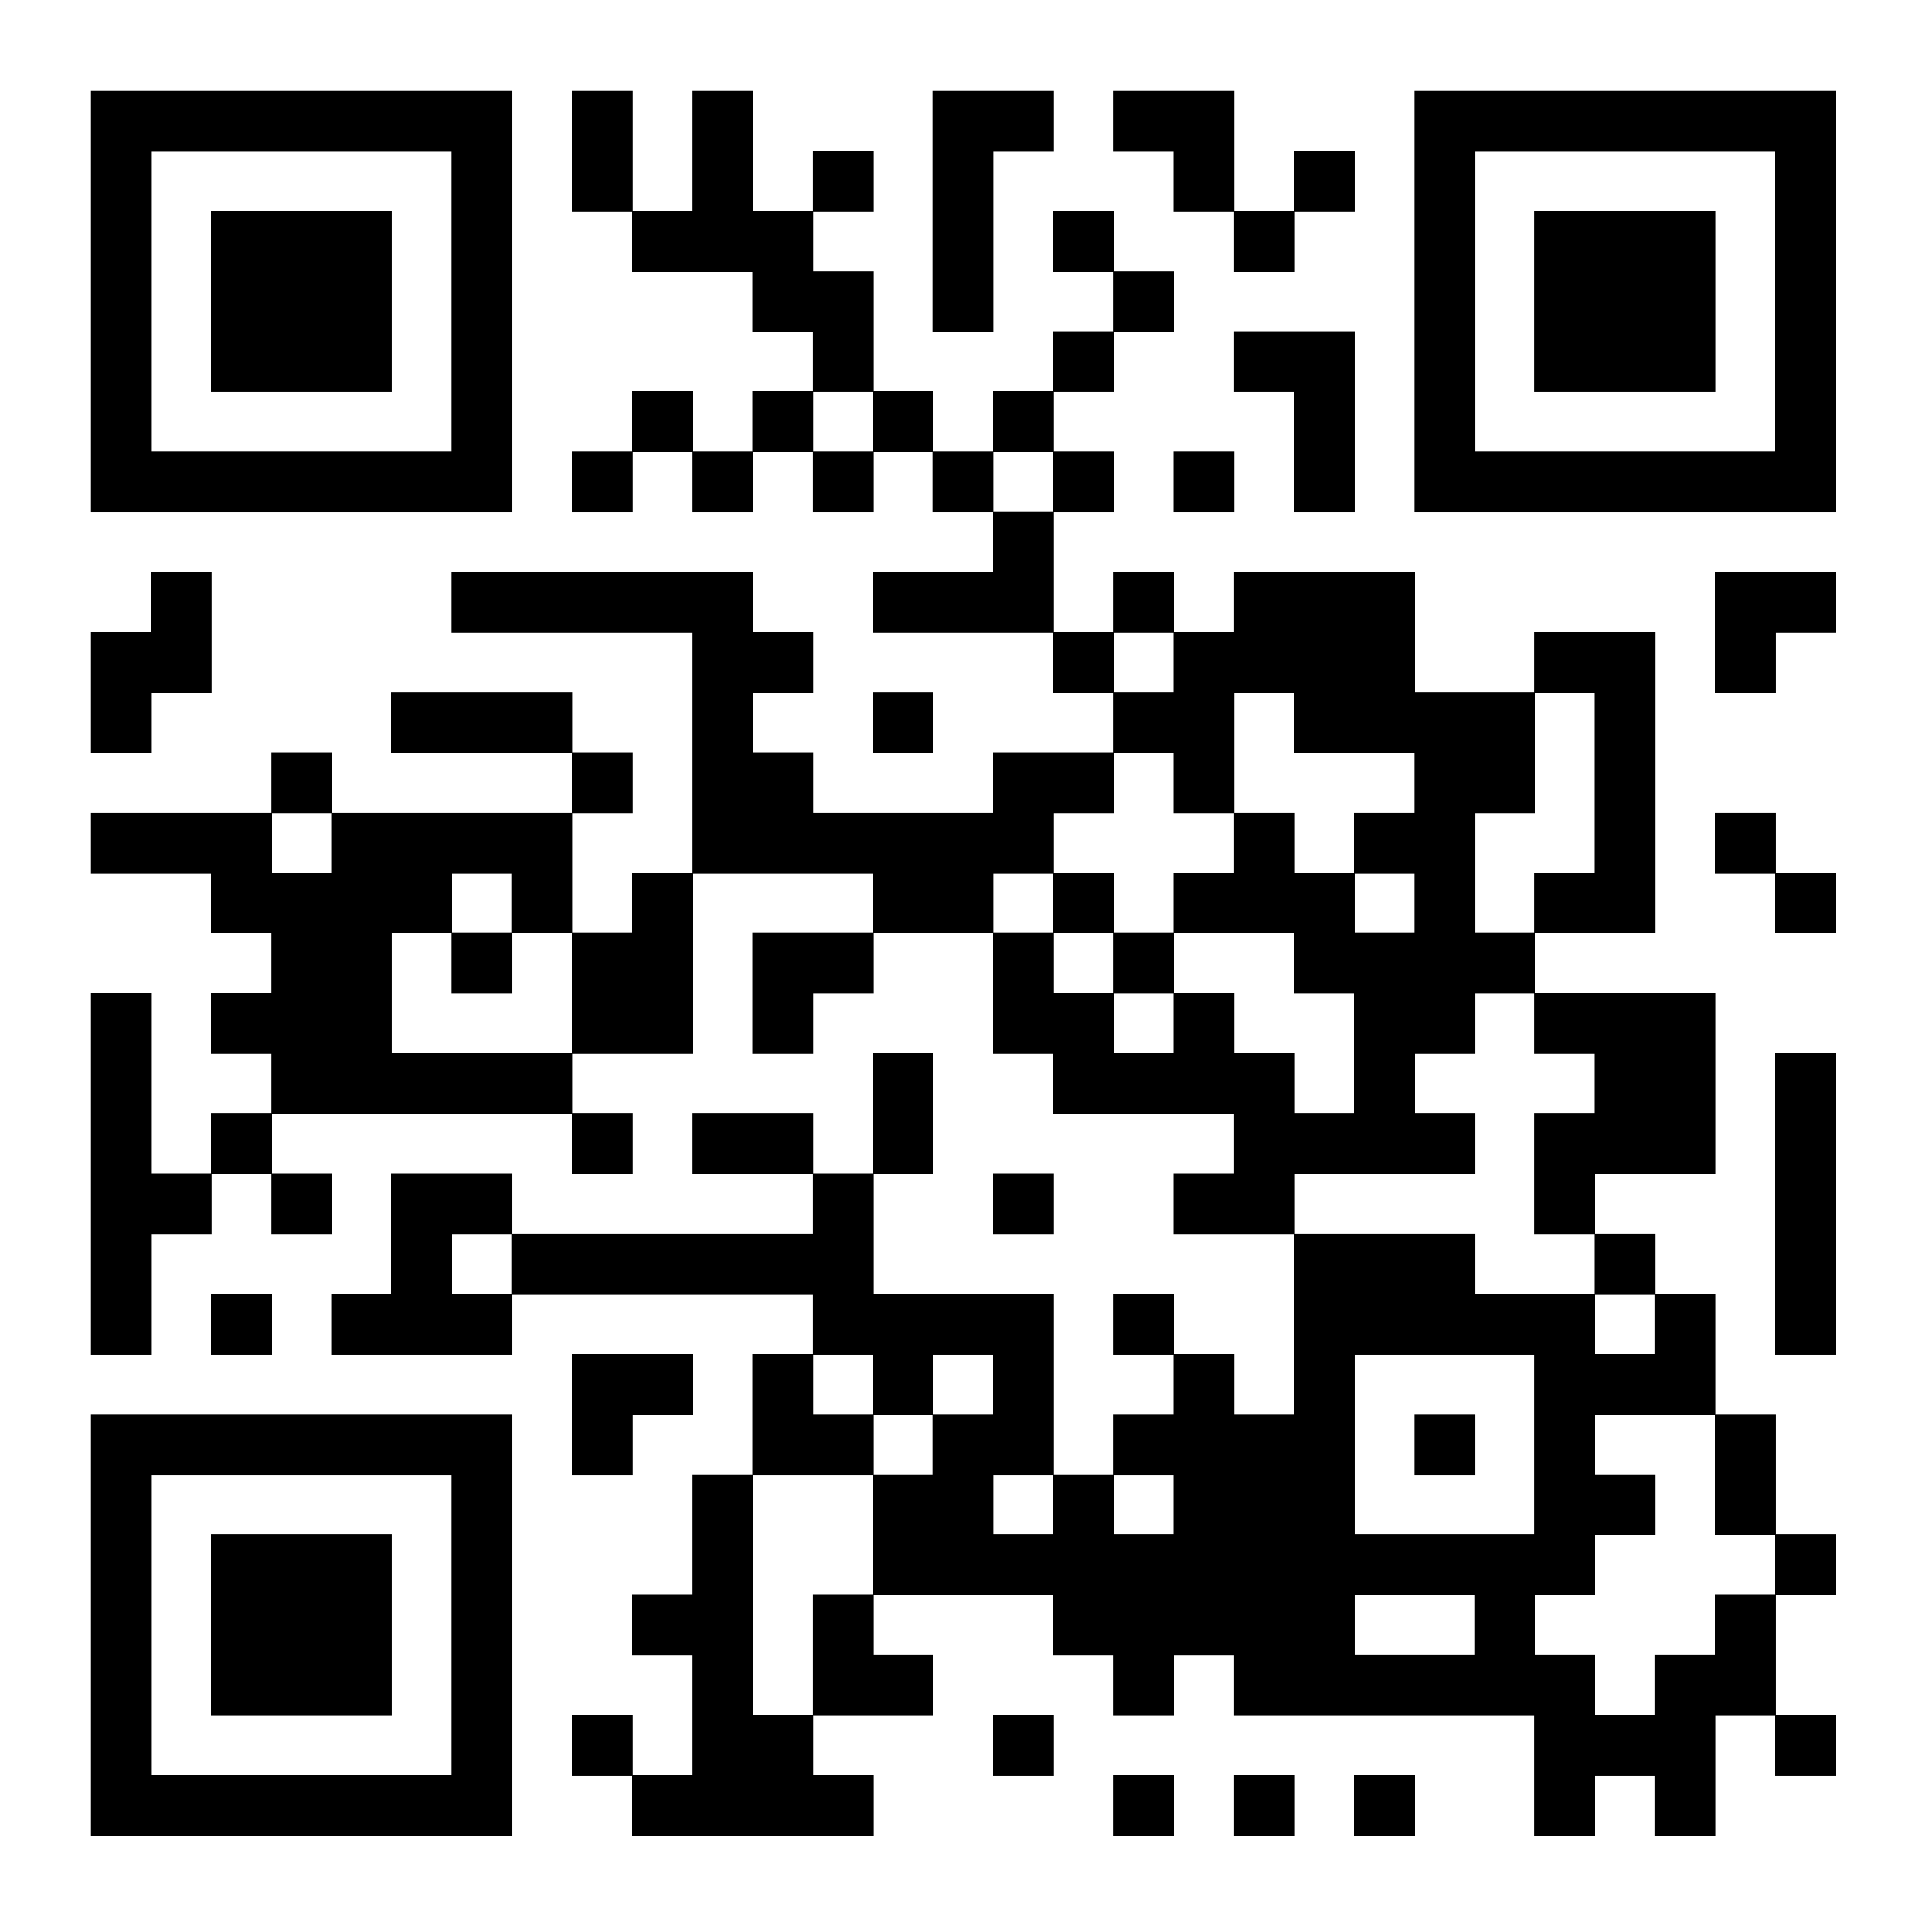

--- Product Safety Information: DAL-002 ---


,1
product_id,DAL-002
name,Extra Virgin Olive Oil
origin,"Tuscany, Italy"
safety_status,DOP Certified
allergens,None
expiry,2026-06-15
traceability_url,https://dalgiardino.com/mobile_demo/app4/app4_...


In [6]:
import qrcode
import pandas as pd
from IPython.display import display, Image
import os

class FoodSafetySystem:
    def __init__(self):
        # Simulated database based on the structure of the provided example
        self.db = pd.DataFrame([
            {
                'product_id': 'DAL-001',
                'name': 'Organic Tomato Sauce',
                'origin': 'Parma, Italy',
                'safety_status': 'Certified Organic',
                'allergens': 'None',
                'expiry': '2025-12-01',
                'traceability_url': 'https://dalgiardino.com/mobile_demo/app4/app4_post_scan.html$0'
            },
            {
                'product_id': 'DAL-002',
                'name': 'Extra Virgin Olive Oil',
                'origin': 'Tuscany, Italy',
                'safety_status': 'DOP Certified',
                'allergens': 'None',
                'expiry': '2026-06-15',
                'traceability_url': 'https://dalgiardino.com/mobile_demo/app4/app4_traceability.html$0'
            }
        ])

    def generate_qr(self, product_id):
        """Generates a QR code for a specific product ID."""
        product = self.db[self.db['product_id'] == product_id]
        if product.empty:
            return None

        # Points to the selected local dashboard file
        data = "file:///content/food_safety_dashboard.html"
        qr = qrcode.QRCode(version=1, box_size=10, border=5)
        qr.add_data(data)
        qr.make(fit=True)

        img = qr.make_image(fill_color="black", back_color="white")
        filename = f"{product_id}_qr.png"
        img.save(filename)
        return filename

    def generate_all_qrs(self):
        """Generates QR codes for all products in the database."""
        generated_files = []
        for pid in self.db['product_id']:
            fname = self.generate_qr(pid)
            if fname:
                generated_files.append(fname)
        return generated_files

    def scan_product(self, product_id):
        """Displays data associated with a product ID."""
        product = self.db[self.db['product_id'] == product_id]
        if product.empty:
            print(f"Error: Product {product_id} not found.")
        else:
            print(f"--- Product Safety Information: {product_id} ---")
            display(product.T)

# Initialize the model
safety_model = FoodSafetySystem()

# Generate QR codes for all products
all_qrs = safety_model.generate_all_qrs()
print(f"Generated {len(all_qrs)} QR codes.")

# Display the generated QR codes and their info
for qr_path in all_qrs:
    current_product_id = qr_path.replace('_qr.png', '')
    display_qr_path = qr_path # Default to the generated path

    # Check if this is the DAL-001 product and use the provided QR code
    if current_product_id == 'DAL-001':
        display_qr_path = '/content/fd8c370c-0b94-49dc-8f09-378adf85762b.png'
    # Check if this is the DAL-002 product and use the provided QR code
    elif current_product_id == 'DAL-002':
        display_qr_path = '/content/ad5f027b-edbe-4036-b737-25df43c4829f.png'

    print(f"\nQR Code for: {current_product_id}")
    display(Image(filename=display_qr_path))
    safety_model.scan_product(current_product_id)

In [3]:
from IPython.display import HTML

# Open and display the food_safety_dashboard.html file
with open('/content/food_safety_dashboard.html', 'r') as f:
    html_content = f.read()

display(HTML(html_content))